In [1]:
# Import PyRadtran components using NEW IO system
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd

# Load the configuration from the YAML file
config_path = Path('../config/spectral_config.yaml')
import logging
# change to "DEBUG" if you want to see more output
logging.getLogger('pyradtran').setLevel(logging.DEBUG)

N_timesteps = 10

# stationary simulation at constant altitude, latitude, and longitude but with varying time
ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2025-04-04T08:00:00', periods=N_timesteps, freq='h'),
        'latitude' : ('time', [61.0] * N_timesteps),
        'longitude' : ('time', [22.0] * N_timesteps),
        'altitude' : ('altitude', [0, 1, 5, 10, 25, 50, 100]),
    }
)

# Run a spectral simulation for a single point using NEW IO system
ds_sim = ds.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
)

print("\nSimulation complete with NEW IO system!")
print(f"Dataset variables: {list(ds_sim.data_vars.keys())}")
print(f"Dataset coordinates: {list(ds_sim.coords.keys())}")
print(f"Dataset shape: {ds_sim.dims}")

2025-07-21 23:57:59,477 - pyradtran.interface - INFO - Altitude found as coordinate - using 7 levels for zout: [  0   1   5  10  25  50 100]
2025-07-21 23:57:59,478 - pyradtran.interface - INFO - Auto-generating output path: work/xarray_example_20250721_235759.nc
2025-07-21 23:57:59,484 - pyradtran.interface - INFO - Running 10 simulations across time/location points...
2025-07-21 23:57:59,507 - pyradtran.core - DEBUG - Generated input file: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/notebooks/work/uvspec_20250404_080000_7uhkoy_g.inp
2025-07-21 23:57:59,510 - pyradtran.core - DEBUG - Running uvspec: /opt/libradtran/2.0.4/bin/uvspec < uvspec_20250404_080000_7uhkoy_g.inp > uvspec_20250404_080000_7uhkoy_g.out
2025-07-21 23:58:01,081 - pyradtran.core - DEBUG - uvspec finished successfully for uvspec_20250404_080000_7uhkoy_g.inp.
2025-07-21 23:58:01,083 - pyradtran.io - DEBUG - Initialized parser with columns: ['zout', 'lambda', 'sza', 'edir', 'eglo', 'edn', 'eup',


Simulation complete with NEW IO system!
Dataset variables: ['sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo']
Dataset coordinates: ['time', 'latitude', 'longitude', 'wavelength', 'altitude']
Dataset shape: FrozenMappingWarningOnValuesAccess({'time': 10, 'wavelength': 301, 'altitude': 7})


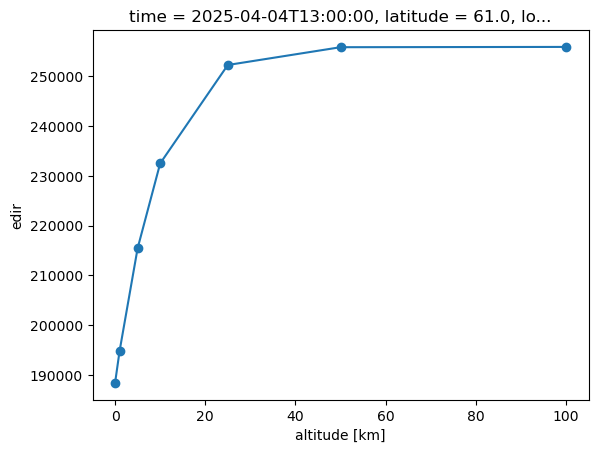

In [2]:
ds_sim.isel(time=5).integrate('wavelength').edir.plot(marker='o', label='Edir')

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/projekt_agmwend/home_rad/Joshua/tmp/ipykernel_2530710/802676703.py:19: SyntaxWarning: invalid escape sequence '\m'
  ax.set_zlabel('$F_\mathrm{dir}^\downarrow$ ($\mathrm{W m^{-2}}$)')


Text(0.5, 0.92, 'NEW IO System - Spectral Direct Irradiance vs Time')

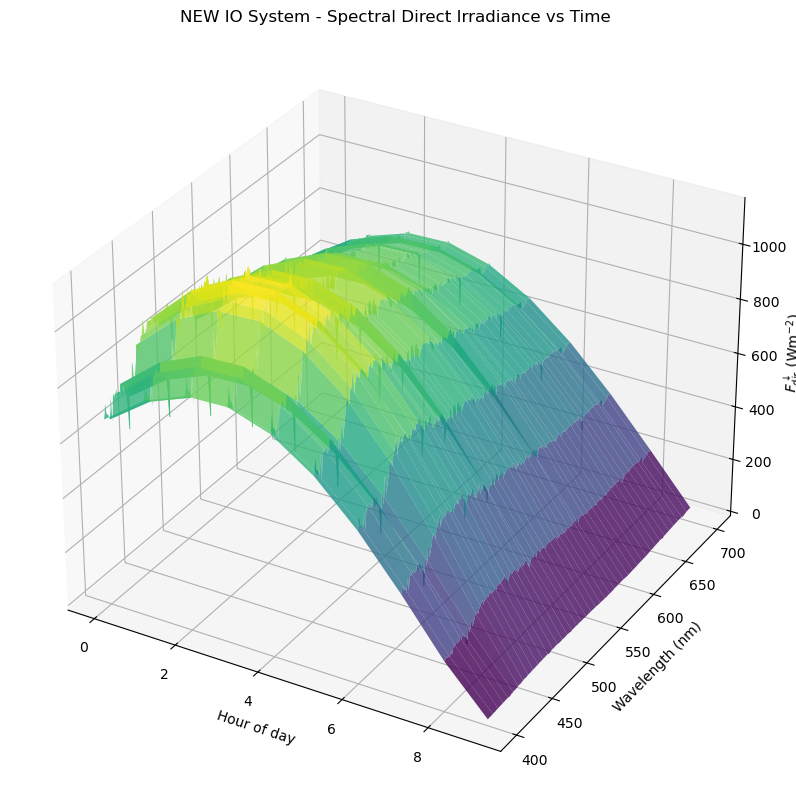

In [10]:
from matplotlib import cm

# make a 3d plot with time on the x-axis, wavelength on the y-axis, and irradiance on the z-axis
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.set_prop_cycle(
    color=cm.viridis(np.linspace(0, 1, len(ds_sim['wavelength'].values))),
)

x = np.arange(len(ds_sim['time'].values))
y = ds_sim['wavelength'].values
z = ds_sim['edir'].values.T
X, Y = np.meshgrid(x, y)

ax.plot_surface(X, Y, z, cmap=cm.viridis, edgecolor='none', alpha=0.8)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Wavelength (nm)')
ax.set_zlabel('$F_\mathrm{dir}^\downarrow$ ($\mathrm{W m^{-2}}$)')

plt.tight_layout()
plt.title('NEW IO System - Spectral Direct Irradiance vs Time')